In [17]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [3]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [19]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [21]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [4]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [45]:
sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[10], top100['end_UTC'].iloc[10]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-01-03T02:10:05.000,2023-01-03T08:15:00.000,STIX,L1,SCI,sci-xray-spec,V04,2301033171


In [46]:
sci_files = Fido.fetch(sci_query[0][0])
sci_data = Product(sci_files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [50]:
df_test = get_stix_df(sci_data, energy_ranges)
df_test

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2023-01-03 02:10:05.943,6.720000,2.200000
2023-01-03 02:10:15.193,7.480000,2.206667
2023-01-03 02:10:32.293,7.560494,2.135802
2023-01-03 02:10:40.643,8.800000,2.440000
2023-01-03 02:10:49.093,7.370732,2.246341
...,...,...
2023-01-03 08:14:56.843,7.142857,1.885714
2023-01-03 08:14:57.543,5.942857,2.485714
2023-01-03 08:14:58.243,6.400000,2.371429
2023-01-03 08:14:58.943,7.542857,2.228571


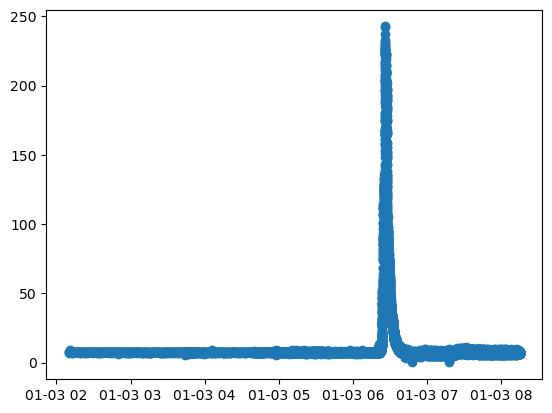

In [48]:
plt.scatter(df_test.index, df_test['25.0 keV-50.0 keV'])

In [49]:
print(df_test.index.freq)

None


In [22]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L1_stix-sci-xray-spec_20240520T022959-20240520T083459_V04_2405209781-50804.fits:   0%|          | 0.00/3.…

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [23]:
listind100 = top100.index.tolist()
diff = set(listind100)-set(indices)
len(diff)

0

In [28]:
df_list_rs = []
for df in df_list:
    df_resampled = df.resample('s')
    df_list_rs.append(df_resampled)

In [24]:
df_list[0]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-07-22 21:25:24.318,6.036000,1.762000
2024-07-22 21:25:44.318,6.108000,1.826000
2024-07-22 21:26:04.318,6.476000,1.650000
2024-07-22 21:26:24.318,6.648000,1.670000
2024-07-22 21:26:44.318,6.652000,1.682000
...,...,...
2024-07-23 03:29:38.668,8.355556,5.111111
2024-07-23 03:29:43.318,7.683333,5.025000
2024-07-23 03:29:48.068,8.476596,4.791489
2024-07-23 03:29:52.768,8.765957,5.336170


In [29]:
df_list_rs[0]

In [ ]:
df_list_rs.index

In [35]:
df_list_rs = df_list.copy()
for df in df_list_rs:
    df.index = parse_time(df.index).datetime
    df = df.resample('s')

In [37]:
df_list_rs[10]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2023-01-03 02:10:05.943,6.720000,2.200000
2023-01-03 02:10:15.193,7.480000,2.206667
2023-01-03 02:10:32.293,7.560494,2.135802
2023-01-03 02:10:40.643,8.800000,2.440000
2023-01-03 02:10:49.093,7.370732,2.246341
...,...,...
2023-01-03 08:14:56.843,7.142857,1.885714
2023-01-03 08:14:57.543,5.942857,2.485714
2023-01-03 08:14:58.243,6.400000,2.371429
2023-01-03 08:14:58.943,7.542857,2.228571
